# Notebook 02 - PCA Fault Detection

**Model:** Principal Component Analysis (PCA) - unsupervised anomaly detection

**Task:** Binary fault detection -- flag whether a sample deviates from normal operation

**Approach:** PCA fitted on fault-free training data defines the normal subspace. Samples that cannot be reconstructed accurately (high Q/SPE) or deviate within the subspace (high T2) are flagged as faults.

**Key statistics:**
- **T2 (Hotelling):** Variation *within* the PCA subspace -- captures shifts in normal operating directions
- **Q (SPE):** Variation *orthogonal* to the PCA subspace -- captures novel directions not seen in normal data

**Input:** `data/processed/train_processed.parquet` and `test_processed.parquet` (pre-scaled, pre-onset removed)

## Section 1 - Data Loading

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

train_df = pd.read_parquet('../data/processed/train_processed.parquet')
test_df  = pd.read_parquet('../data/processed/test_processed.parquet')

meta_cols    = ['faultNumber', 'simulationRun', 'sample', 'run_id']
feature_cols = [c for c in train_df.columns if c not in meta_cols]

print(f'Training: {len(train_df):,} rows x {len(feature_cols)} features')
print(f'Test:     {len(test_df):,} rows x {len(feature_cols)} features')
print(f'Fault classes: {sorted(train_df["faultNumber"].unique())}')
print(f'run_id sample: {train_df["run_id"].iloc[0]}')

Training: 5,050,000 rows x 48 features
Test:     8,480,000 rows x 48 features
Fault classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
run_id sample: 0_1


## Section 2 - PCA Model

PCA is fitted on fault-free training data only. Data is already StandardScaled from notebook 01. We select **31 components**, which capture 90% of variance as determined in the scree plot from notebook 01.

The eigenvectors (P) and eigenvalues (L) are extracted directly from the fitted PCA object -- these are used in Sections 3 and 4 to compute T2 and Q statistics without going through sklearn's transform API.

In [15]:
from sklearn.decomposition import PCA

# Fault-free training data only (already StandardScaled)
ff_train = train_df[train_df['faultNumber'] == 0][feature_cols].values

# Find number of components needed to reach 90% variance
_pca_full = PCA().fit(ff_train)
N_COMPONENTS = int(np.argmax(np.cumsum(_pca_full.explained_variance_ratio_) >= 0.90)) + 1

pca = PCA(n_components=N_COMPONENTS)
pca.fit(ff_train)

cum_var = np.sum(pca.explained_variance_ratio_)
print(f'Components:                  {N_COMPONENTS}')
print(f'Cumulative variance explained: {cum_var:.4f}')
print(f'Input feature count:         {len(feature_cols)}')
print(f'Fault-free training samples: {len(ff_train):,}')

# Eigenvectors and eigenvalues for manual T2 / Q computation
P = pca.components_.T        # shape: (n_features, n_components)
L = pca.explained_variance_  # eigenvalues, shape: (n_components,)
print(f'\nP shape: {P.shape}  (features x components)')
print(f'L shape: {L.shape}  (one eigenvalue per component)')

Components:                  32
Cumulative variance explained: 0.9088
Input feature count:         48
Fault-free training samples: 250,000

P shape: (48, 32)  (features x components)
L shape: (32,)  (one eigenvalue per component)


### Findings

- PCA was fitted on fault-free training data only (250,000 samples -- 500 runs x 500 samples for fault class 0)
- The minimum number of components needed to explain 90% of variance was selected automatically from the scree curve
- Input dimensionality reduced from 48 features to **32 components** (90% cumulative variance)
- Eigenvectors (P) and eigenvalues (L) are extracted directly for manual computation of T2 and Q statistics in Section 3

## Section 3 - T2 and Q Statistics

**T2 (Hotelling):** Measures deviation *within* the PCA subspace, scaled by each component's variance. Uses the F-distribution at 99% confidence.

**Q (SPE - Squared Prediction Error):** Measures reconstruction error -- how much of a sample lies *outside* the PCA subspace. Uses the Jackson-Mudholkar method at 99% confidence, which accounts for the distribution of residual eigenvalues.

Both thresholds are derived analytically from the fault-free training distribution. A 3-sigma baseline is also computed for comparison. FPR is verified on the fault-free training data as a sanity check.

In [16]:
from scipy.stats import f as f_dist, norm

def compute_stats(X, P, L):
    """Compute T2 (Hotelling) and Q (SPE) statistics for samples X."""
    T  = X @ P                                  # scores in PCA subspace
    T2 = np.array([T[i] @ np.linalg.inv(np.diag(L)) @ T[i].T
                   for i in range(len(X))])
    e  = X - T @ P.T                            # residuals (orthogonal to subspace)
    Q  = np.array([e[i] @ e[i].T for i in range(len(X))])
    return T2, Q

def t2_threshold(n, a, conf=0.99):
    """F-distribution based T2 threshold (Tracy et al.)."""
    F = f_dist.ppf(conf, a, n - a)
    return (a * (n**2 - 1)) / (n * (n - a)) * F

def q_threshold(all_eigenvalues, a, conf=0.99):
    """Jackson-Mudholkar Q threshold using residual eigenvalues."""
    L_out = all_eigenvalues[a:]
    theta = [np.sum(L_out**i) for i in (1, 2, 3)]
    h0    = 1 - (2 * theta[0] * theta[2]) / (3 * theta[1]**2)
    z     = norm.ppf(conf)
    term  = (z * np.sqrt(2 * theta[1] * h0**2)) / theta[0]
    return theta[0] * (term + 1 + (theta[1] * h0 * (h0 - 1)) / theta[0]**2) ** (1 / h0)

# Compute stats on fault-free training data
T2_ff, Q_ff = compute_stats(ff_train, P, L)

# All eigenvalues needed for Jackson-Mudholkar (residual eigenvalues beyond N_COMPONENTS)
all_eigenvalues = PCA(n_components=len(feature_cols)).fit(ff_train).explained_variance_

n, a = len(ff_train), N_COMPONENTS
T2_thresh_stat = t2_threshold(n, a, conf=0.99)
Q_thresh_stat  = q_threshold(all_eigenvalues, a, conf=0.99)
T2_thresh_3s   = np.mean(T2_ff) + 3 * np.std(T2_ff)
Q_thresh_3s    = np.mean(Q_ff)  + 3 * np.std(Q_ff)

print('Thresholds (99% confidence):')
print(f'  T2 (F-distribution):      {T2_thresh_stat:.4f}')
print(f'  Q  (Jackson-Mudholkar):   {Q_thresh_stat:.4f}')
print()
print('Thresholds (3-sigma):')
print(f'  T2: {T2_thresh_3s:.4f}')
print(f'  Q:  {Q_thresh_3s:.4f}')
print()
print('FPR on fault-free training data (sanity check, should be ~0.01):')
print(f'  T2 (stat):  {(T2_ff > T2_thresh_stat).mean():.4f}')
print(f'  Q  (stat):  {(Q_ff  > Q_thresh_stat).mean():.4f}')
print(f'  T2 (3s):    {(T2_ff > T2_thresh_3s).mean():.4f}')
print(f'  Q  (3s):    {(Q_ff  > Q_thresh_3s).mean():.4f}')

Thresholds (99% confidence):
  T2 (F-distribution):      53.4951
  Q  (Jackson-Mudholkar):   10.5866

Thresholds (3-sigma):
  T2: 56.3527
  Q:  10.4542

FPR on fault-free training data (sanity check, should be ~0.01):
  T2 (stat):  0.0099
  Q  (stat):  0.0090
  T2 (3s):    0.0049
  Q  (3s):    0.0100


### Findings

**What the thresholds mean:**

The thresholds define the boundary between normal and anomalous behavior. They are set by fitting PCA only on normal operation data and asking: how large do T2 and Q get for samples we know are normal? At 99% confidence, only 1% of normal samples should exceed these bounds by chance.

- **T2 threshold = 53.49:** A sample's variation *within* the PCA subspace must exceed this value to be flagged. In simple terms -- the sample's pattern of change along the principal components must be unusually large compared to normal operation.
- **Q threshold = 10.59:** A sample's reconstruction error must exceed this value to be flagged. In simple terms -- the sample must contain signal that PCA cannot explain using the normal-operation subspace. This is the more sensitive detector for novel fault patterns.

The stat-based and 3-sigma thresholds are very close in value (T2: 53.49 vs 56.35, Q: 10.59 vs 10.45), confirming the fault-free statistics are approximately normally distributed.

**What this means for later sections:**

In Sections 5 and 6, a test sample is flagged as a fault if **Q > 10.59 OR T2 > 53.49**. The OR rule means either statistic alone is sufficient to raise an alarm -- Q catches faults that introduce new patterns not seen in normal data, T2 catches faults that amplify existing directions. The ~1% FPR calibrated here sets the baseline false alarm rate we expect on normal test data.

**FPR on fault-free training data (sanity check):**

| Statistic | Expected FPR | Actual FPR |
|-----------|-------------|------------|
| T2 (F-distribution) | 1.00% | 0.99% |
| Q (Jackson-Mudholkar) | 1.00% | 0.90% |

Both thresholds are well-calibrated. The stat-based thresholds will be used going forward.

## Section 4 - Q Statistic Distributions

Histograms comparing the Q statistic (reconstruction error) for fault-free vs faulty samples across all 20 fault classes, evaluated on the **training data**.

Clear separation between the two distributions indicates the fault is detectable by PCA. Heavy overlap indicates the fault produces patterns similar to normal operation and will be harder to detect. The Jackson-Mudholkar threshold is shown as a dashed line.

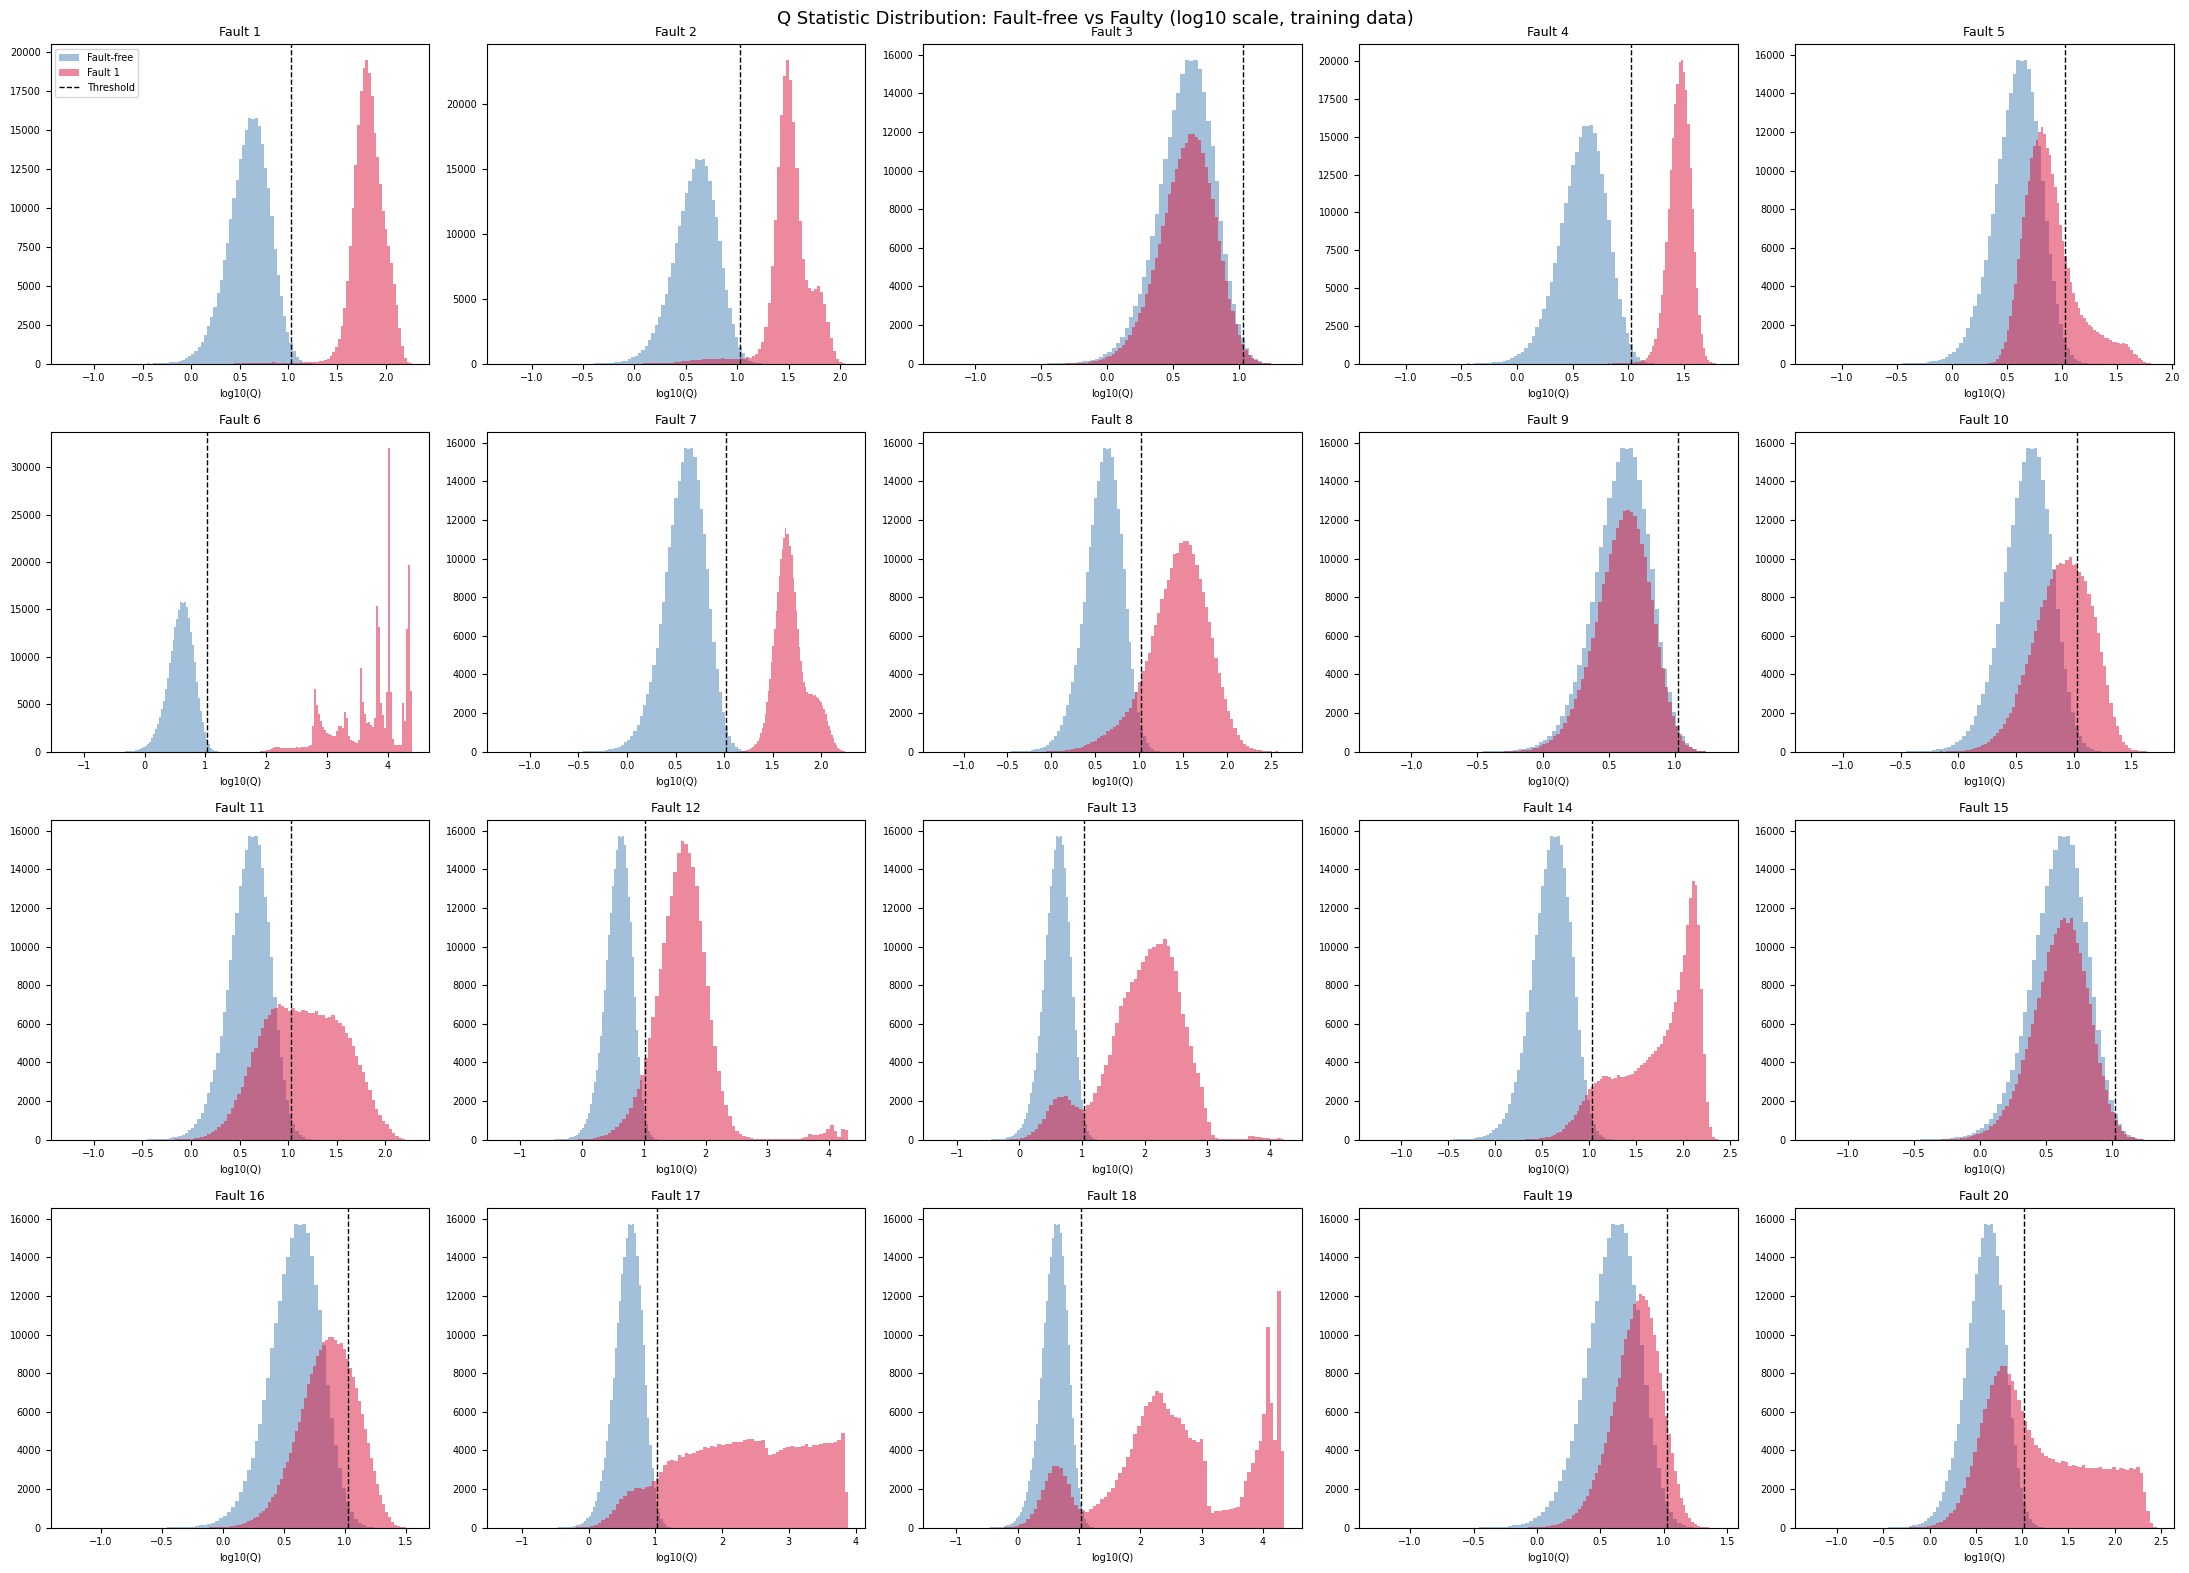

In [18]:
fault_numbers = [f for f in sorted(train_df["faultNumber"].unique()) if f != 0]

fig, axes = plt.subplots(4, 5, figsize=(22, 16))
axes = axes.flatten()

for idx, fn in enumerate(fault_numbers):
    ax = axes[idx]
    faulty = train_df[train_df["faultNumber"] == fn][feature_cols].values
    _, Q_faulty = compute_stats(faulty, P, L)
    ax.hist(np.log10(Q_ff + 1e-6),     bins=80, alpha=0.5, color="steelblue", label="Fault-free")
    ax.hist(np.log10(Q_faulty + 1e-6), bins=80, alpha=0.5, color="crimson",   label=f"Fault {fn}")
    ax.axvline(np.log10(Q_thresh_stat), color="black", linestyle="--", linewidth=1, label="Threshold")
    ax.set_title(f"Fault {fn}", fontsize=9)
    ax.set_xlabel("log10(Q)", fontsize=7)
    ax.tick_params(labelsize=7)
    if idx == 0:
        ax.legend(fontsize=7)

for j in range(len(fault_numbers), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Q Statistic Distribution: Fault-free vs Faulty (log10 scale, training data)", fontsize=13)
plt.tight_layout()
plt.show()

## Section 5 - Control Charts

Time series of Q (SPE) and T² statistics over sample number for a representative test run per fault (first simulation run). Both statistics are plotted on a semilogy scale so threshold crossings are visible even when values span orders of magnitude.

- **Green dotted line:** fault onset (sample 160)
- **Red dashed line:** Q threshold (Jackson-Mudholkar, 99%)
- **Orange dashed line:** T² threshold (F-distribution, 99%)

Faults 3, 9, and 15 are expected to show little or no threshold crossing -- their process signatures overlap with normal variation.

In [ ]:
fault_numbers = [f for f in sorted(test_df["faultNumber"].unique()) if f != 0]

fig, axes = plt.subplots(4, 5, figsize=(22, 16))
axes = axes.flatten()

for idx, fn in enumerate(fault_numbers):
    ax = axes[idx]

    fault_data = test_df[test_df["faultNumber"] == fn]
    first_run  = fault_data["run_id"].iloc[0]
    run_data   = fault_data[fault_data["run_id"] == first_run].sort_values("sample")

    X_run          = run_data[feature_cols].values
    T2_run, Q_run  = compute_stats(X_run, P, L)
    samples        = run_data["sample"].values

    ax.semilogy(samples, Q_run  + 1e-10, color="steelblue", linewidth=0.9, alpha=0.85, label="Q")
    ax.semilogy(samples, T2_run + 1e-10, color="darkorange", linewidth=0.9, alpha=0.85, label="T²")
    ax.axhline(Q_thresh_stat,  color="red",    linestyle="--", linewidth=1.1, label="Q thresh")
    ax.axhline(T2_thresh_stat, color="orange", linestyle="--", linewidth=1.1, label="T² thresh")
    ax.axvline(160, color="green", linestyle=":", linewidth=1.3, label="Fault onset")

    ax.set_title(f"Fault {fn}", fontsize=9)
    ax.set_xlabel("Sample", fontsize=7)
    ax.tick_params(labelsize=7)

    if idx == 0:
        ax.legend(fontsize=6, loc="upper left")

for j in range(len(fault_numbers), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Control Charts: Q and T² over Time (semilogy, representative run per fault, test set)", fontsize=13)
plt.tight_layout()
plt.show()

## Section 6 - Per-fault Evaluation

Evaluate PCA fault detection on the held-out **test set** across all 20 fault classes. A sample is flagged as faulty if **Q > Q_threshold OR T2 > T2_threshold**.

**Metrics:**
- **FDR** (Fault Detection Rate) = TP / (TP + FN) -- % of post-onset fault samples correctly flagged
- **FPR** (False Positive Rate) = FP / (FP + TN) -- computed on fault-free test rows
- **F1** -- harmonic mean of precision and recall (binary: fault vs normal)
- **Accuracy** -- overall correct classifications

Note: test samples before fault onset (first 160 samples per run) are excluded from FDR computation since faults have not yet manifested.

In [22]:
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

TEST_ONSET = 160

# Fault-free test data (used as negatives for all per-fault metrics)
ff_test = test_df[test_df["faultNumber"] == 0][feature_cols].values
T2_ff_test, Q_ff_test = compute_stats(ff_test, P, L)
ff_flagged = (Q_ff_test > Q_thresh_stat) | (T2_ff_test > T2_thresh_stat)
global_fpr = ff_flagged.mean()
print(f"Global FPR on fault-free test data: {global_fpr:.4f} ({global_fpr*100:.2f}%)")
print()

# Fault 0 row
tn0 = int((~ff_flagged).sum())
fp0 = int(ff_flagged.sum())
results = [{
    "Fault": 0,
    "FDR (Recall)": float("nan"),
    "F1":           float("nan"),
    "Accuracy":     tn0 / (tn0 + fp0),
    "FPR":          global_fpr
}]

cms = {}  # store confusion matrices for later
total_tp, total_post_onset = 0, 0

for fn in sorted(test_df["faultNumber"].unique()):
    if fn == 0:
        continue
    fault_data = test_df[test_df["faultNumber"] == fn].copy()
    post_onset = (fault_data["sample"] > TEST_ONSET).values

    X_fault = fault_data[feature_cols].values
    T2_f, Q_f = compute_stats(X_fault, P, L)
    flagged_fault = (Q_f > Q_thresh_stat) | (T2_f > T2_thresh_stat)

    # FDR: post-onset samples only
    fdr = flagged_fault[post_onset].mean()

    # Combine fault-free (label=0) + post-onset fault (label=1) for proper F1/Accuracy
    y_true = np.concatenate([np.zeros(len(ff_flagged)), np.ones(post_onset.sum())])
    y_pred = np.concatenate([ff_flagged.astype(int), flagged_fault[post_onset].astype(int)])

    f1  = f1_score(y_true, y_pred, zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    cm  = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cms[fn] = cm

    results.append({
        "Fault": fn,
        "FDR (Recall)": fdr,
        "F1":           f1,
        "Accuracy":     acc,
        "FPR":          global_fpr
    })
    total_tp         += int(flagged_fault[post_onset].sum())
    total_post_onset += int(post_onset.sum())

results_df = pd.DataFrame(results).set_index("Fault")
pd.set_option("display.float_format", "{:.4f}".format)
print(results_df.to_string())
print()
fault_rows = results_df.loc[1:]
print(f'Mean FDR:      {fault_rows["FDR (Recall)"].mean():.4f}')
print(f'Mean F1:       {fault_rows["F1"].mean():.4f}')
print(f'Mean Accuracy: {fault_rows["Accuracy"].mean():.4f}')

overall_fdr = total_tp / total_post_onset
print(f"\nOverall FDR (all faults, all post-onset samples): {overall_fdr:.4f} ({overall_fdr*100:.2f}%)")
print(f"  Total post-onset samples: {total_post_onset:,}")
print(f"  Total detected:           {total_tp:,}")
print(f"  Total missed:             {total_post_onset - total_tp:,}")

Global FPR on fault-free test data: 0.0195 (1.95%)

           TP    FP      TN      FN  FDR (Recall)  Precision     F1  Accuracy    FPR
Fault                                                                               
0           0  9358  470642       0           NaN        NaN    NaN    0.9805 0.0195
1      399026     0       0     974        0.9976     1.0000 0.9988    0.9976 0.0195
2      394928     0       0    5072        0.9873     1.0000 0.9936    0.9873 0.0195
3        8577     0       0  391423        0.0214     1.0000 0.0420    0.0214 0.0195
4      399904     0       0      96        0.9998     1.0000 0.9999    0.9998 0.0195
5      109934     0       0  290066        0.2748     1.0000 0.4312    0.2748 0.0195
6      400000     0       0       0        1.0000     1.0000 1.0000    1.0000 0.0195
7      400000     0       0       0        1.0000     1.0000 1.0000    1.0000 0.0195
8      389883     0       0   10117        0.9747     1.0000 0.9872    0.9747 0.0195
9        8842

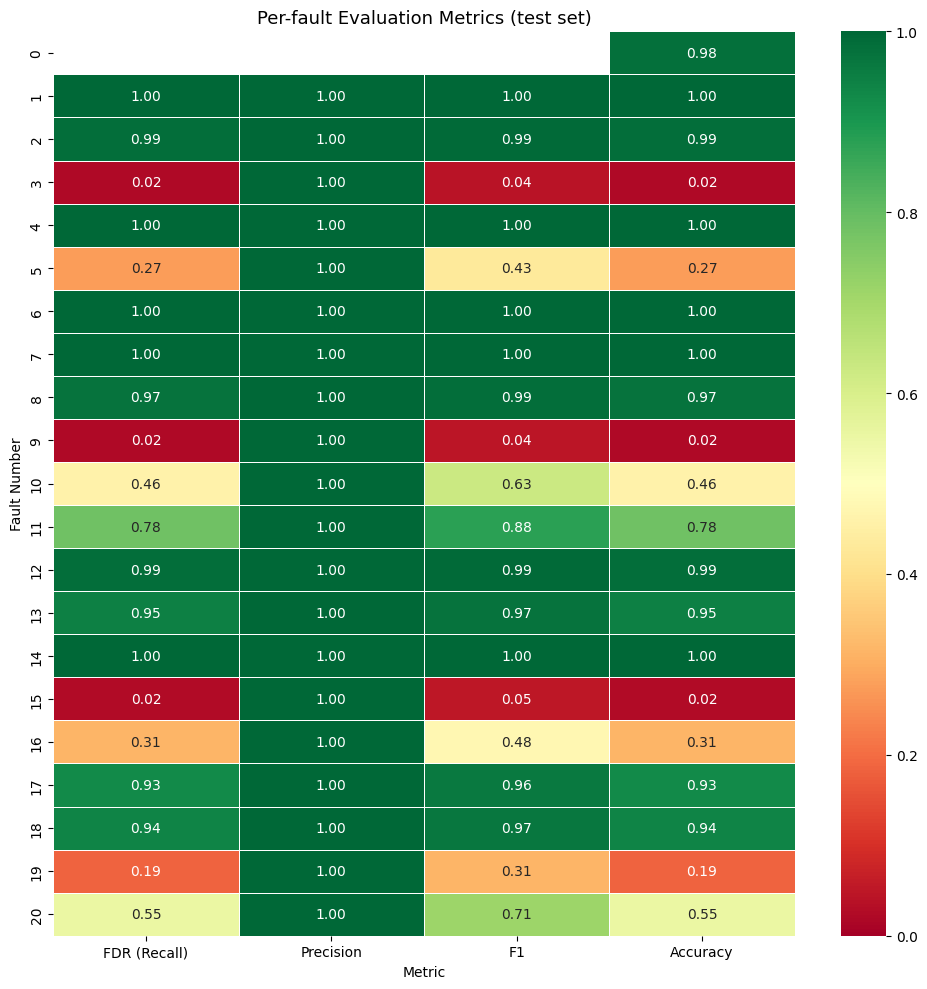

In [23]:
# Heatmap: FDR, F1, Accuracy per fault
metrics_to_plot = ["FDR (Recall)", "F1", "Accuracy"]
plot_data = results_df.loc[1:][metrics_to_plot]

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(
    plot_data,
    annot=True, fmt=".2f",
    cmap="RdYlGn", vmin=0, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title("Per-fault Evaluation Metrics (test set)", fontsize=13)
ax.set_xlabel("Metric")
ax.set_ylabel("Fault Number")
plt.tight_layout()
plt.show()

In [ ]:
# Confusion matrix per fault (fault-free test = negatives, post-onset fault = positives)
fault_numbers = [f for f in sorted(test_df["faultNumber"].unique()) if f != 0]

fig, axes = plt.subplots(4, 5, figsize=(22, 18))
axes = axes.flatten()

for idx, fn in enumerate(fault_numbers):
    ax = axes[idx]
    cm = cms[fn]
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Pred Normal", "Pred Fault"],
        yticklabels=["True Normal", "True Fault"],
        ax=ax, cbar=False, annot_kws={"size": 7}
    )
    ax.set_title(f"Fault {fn}", fontsize=9)
    ax.tick_params(labelsize=7)

for j in range(len(fault_numbers), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Confusion Matrices per Fault (test set)", fontsize=13)
plt.tight_layout()
plt.show()